# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary two hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

In [ ]:

# Install astronomaly from GitHub if not already available
try:
    import astronomaly
except ModuleNotFoundError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "git+https://github.com/MichelleLochner/astronomaly.git"
    ])
    import importlib, astronomaly
    importlib.reload(astronomaly)

print("astronomaly version:", astronomaly.__version__)

from astronomaly.anomaly_detection import protege, human_loop_learning
import re
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path
from scipy.spatial.distance import cdist

subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow==14.0.2", "-q"])

data_path = "../outputs/%s/embeddings/"
%matplotlib inline

astronomaly version: 2.0



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Retrieval Metric: nDCG@10

`nDCGk_avg` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

In [52]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    #print(f"processed {idx_ref} ref proj from class {ref_class}")
    return (np.asarray(res).mean())

## Single-Run Baseline

Quick inspection of one training run: loads test-split embeddings and computes nDCG@10 across all 17 morphological classes.

In [53]:
# Specify the run directory
#run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_w10.0_s97_20260323_1533'
#run_directory='/users/ncerardi/sk030/projectG_supervised_latent_radiogals/outputs/run_both_closest_full_p0.5_s97_20260323_1750'
run_directory='/users/mbredber/p3_SUPLAT/outputs/run_no_val_run_f1_sw3_20260521_1641'


# Extract the run name from the directory path
run_name = Path(run_directory).name

# =============================================================================
# Cosine distance (embedding) vs Hamming distance (labels)
# =============================================================================
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42
# =============================================================================

emb_dir = Path(f'../outputs/{run_name}/data')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

result_w10 = []
#Show results for all classes
for class_id in range(17):
    nDGG10_class = nDCGk_avg(proj, labels, class_id)
    result_w10.append(nDGG10_class)
    print(f"Class: {class_id} | nDCG@10 = {nDGG10_class}")

Class: 0 | nDCG@10 = 0.6051794741084231
Class: 1 | nDCG@10 = 0.8389967195076221
Class: 2 | nDCG@10 = 0.3286121727078525
Class: 3 | nDCG@10 = 0.22525036353590452
Class: 4 | nDCG@10 = 0.32366588966201887
Class: 5 | nDCG@10 = 0.4363749434286777
Class: 6 | nDCG@10 = 0.17110251646792293
Class: 7 | nDCG@10 = 0.2193473200316428
Class: 8 | nDCG@10 = 0.29147535429527716
Class: 9 | nDCG@10 = 0.07367063272686407
Class: 10 | nDCG@10 = 0.31737923712563093
Class: 11 | nDCG@10 = 0.35801562211448507
Class: 12 | nDCG@10 = 0.08654765638378709
Class: 13 | nDCG@10 = 0.026053130374996722
Class: 14 | nDCG@10 = 0.0
Class: 15 | nDCG@10 = 0.05915185854680784
Class: 16 | nDCG@10 = 0.032129469524552534


## Multi-Run Comparison

Loads test embeddings from every `run_no_val_run_f*_sw*` run directory, computes per-class nDCG@10 for each, and collects the results into `run_results` for plotting. Uses `EVAL_SPLIT` rather than `SPLIT` to avoid overwriting the active-learning split variable set later.

In [62]:
OUTPUTS_ROOT = Path("/users/mbredber/p3_SUPLAT/outputs")
EVAL_SPLIT = "test"
N_CLASSES = 20

run_dirs = sorted(OUTPUTS_ROOT.glob("run_no_val_run_f*_sw*"))

run_results = []
for rd in run_dirs:
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))
    data_dir = rd / "data"
    proj   = np.load(data_dir / f"{EVAL_SPLIT}_projections.npy")
    labels = np.load(data_dir / f"{EVAL_SPLIT}_labels.npy")
    ndcg   = [nDCGk_avg(proj, labels, c) for c in range(N_CLASSES)]
    run_results.append(dict(name=rd.name, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")

  loaded run_no_val_run_f0.2_sw10_20260521_1725  (f=0.2, sw=10.0)
  loaded run_no_val_run_f0.5_sw10_20260521_1728  (f=0.5, sw=10.0)
  loaded run_no_val_run_f0_sw1_20260521_1517  (f=0.0, sw=1.0)
  loaded run_no_val_run_f1_sw0.5_20260521_1537  (f=1.0, sw=0.5)
  loaded run_no_val_run_f1_sw10_20260521_1723  (f=1.0, sw=10.0)
  loaded run_no_val_run_f1_sw1_20260521_1609  (f=1.0, sw=1.0)
  loaded run_no_val_run_f1_sw3_20260521_1641  (f=1.0, sw=3.0)

Loaded 7 runs.


### nDCG@10 Results Plot

Each point is one (run, class) pair. **Colour** encodes `sw` on a log-scaled viridis gradient (dark = low, bright = high). **Filled fraction of the circle** encodes `f`: an empty circle means no labels were used; a fully filled circle means all labels were used.

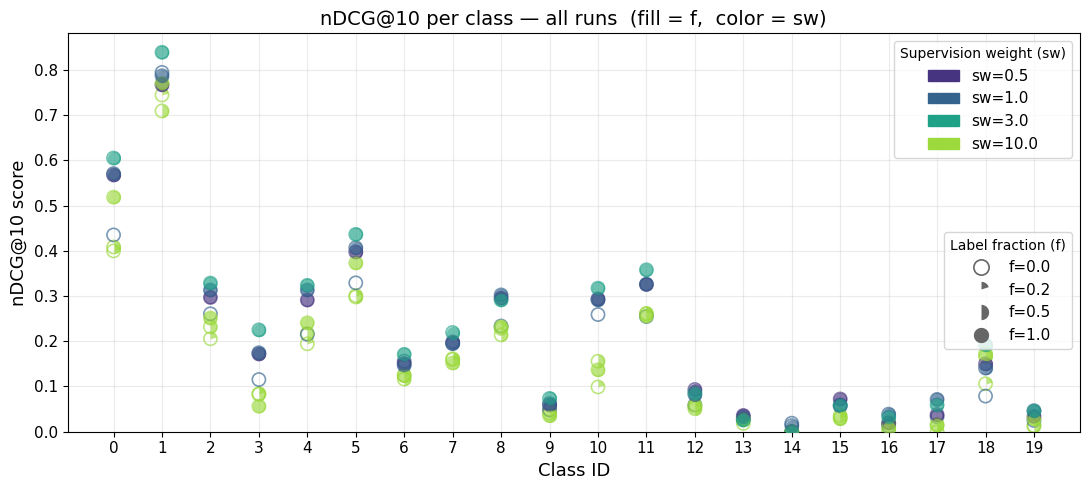

In [63]:
from matplotlib.path import Path as MPath

def pie_marker(fraction):
    """Wedge Path covering `fraction` of the unit circle, clockwise from 12 o'clock."""
    if fraction >= 1.0:
        n = 100
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        verts = np.column_stack([np.cos(t), np.sin(t)])
        codes = [MPath.MOVETO] + [MPath.LINETO] * (n - 1) + [MPath.CLOSEPOLY]
        return MPath(np.vstack([verts, verts[:1]]), codes)
    n = 50
    t = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi * fraction, n)
    verts = [(0.0, 0.0)] + list(zip(np.cos(t), np.sin(t))) + [(0.0, 0.0)]
    codes = [MPath.MOVETO] + [MPath.LINETO] * n + [MPath.CLOSEPOLY]
    return MPath(verts, codes)


f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results))

cmap    = plt.cm.viridis
sw_log  = np.log10(sw_vals)
sw_norm = (sw_log - sw_log.min()) / (sw_log.max() - sw_log.min() + 1e-9)
sw_color = {sw: cmap(0.15 + 0.70 * v) for sw, v in zip(sw_vals, sw_norm)}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(N_CLASSES)
S, ALPHA = 90, 0.65

for r in run_results:
    color = sw_color[r['sw']]
    ax.scatter(x, r['ndcg'], facecolors='none', edgecolors=[color] * N_CLASSES,
               marker='o', s=S, linewidths=1.2, zorder=2, alpha=ALPHA)
    if r['f'] > 0:
        ax.scatter(x, r['ndcg'], color=color, marker=pie_marker(r['f']),
                   s=S, linewidths=0, zorder=3, alpha=ALPHA)

ax.set_xlabel("Class ID", fontsize=13)
ax.set_ylabel("nDCG@10 score", fontsize=13)
ax.set_ylim([0, None])
ax.set_xticks(x)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.25)

LFS, LMS = 11, 11  # legend fontsize, markersize
grey = (0.4, 0.4, 0.4)

f_handles = []
for f in f_vals:
    if f == 0:
        h = mlines.Line2D([], [], linestyle='None', marker='o', markersize=LMS,
                          markerfacecolor='none', markeredgecolor=grey,
                          markeredgewidth=1.2, label=f'f={f}')
    else:
        h = mlines.Line2D([], [], linestyle='None', marker=pie_marker(f), markersize=LMS,
                          markerfacecolor=grey, markeredgecolor='none', label=f'f={f}')
    f_handles.append(h)

sw_handles = [
    mpatches.Patch(color=sw_color[sw], label=f'sw={sw}')
    for sw in sw_vals
]

# Stack both legends at upper right
leg_sw = ax.legend(handles=sw_handles, title='Supervision weight (sw)',
                   loc='upper right', bbox_to_anchor=(1.0, 1.0),
                   framealpha=0.8, fontsize=LFS)
ax.add_artist(leg_sw)
ax.legend(handles=f_handles, title='Label fraction (f)',
          loc='upper right', bbox_to_anchor=(1.0, 0.52),
          framealpha=0.8, fontsize=LFS)

ax.set_title("nDCG@10 per class — all runs  (fill = f,  color = sw)", fontsize=14)
plt.tight_layout()
plt.show()

## Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring
| Score | Classes |
|-------|---------|
| 5 | `xshaped` (9), `unknown` (19) |
| 4 | `cluster` (16), `merger` (17), `diffuse` (18), `sshaped` (6) |
| 3 | `restarted` (15), `onesided` (14), `banding` (13), `cshaped` (5), `wings` (8), `misaligned` (7), `spiral` (3), `relaxed` (4) |
| 2 | `fri` (0), `frii` (1), `hybrid` (2), `straight` (10), `multihotspots` (11), `continuous` (12) |
| 1 | No positive label in any of the above |

## Protege Active Learning Integration

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

In [64]:
_idx = np.load(
    "/users/mbredber/p3_SUPLAT/outputs/run_tester_f0_sw1_20260521_1110/data/train_idx.npy"
)
print(_idx.dtype, _idx.shape, _idx[:5])

int64 (4861,) [3358 7324 3996 6643  657]


### Verify Split Index

Sanity-check that the training-split index file loads correctly. These are positional row indices into the full source catalogue CSV, used to recover source names and metadata.

**Index dtype:** `int64` — positional row indices into the images array (same row order as the CSV).
Join to CSV via `csv_df.iloc[idx_arr]` to recover `Source_Name` and metadata.

### Configuration

Set the run directory, data paths, split, morphology tier definitions, and active learning hyperparameters. Adjust `INITIAL_STEPS`, `N_LABELS_TOTAL`, and `EI_TRADEOFF` to control the labelling budget and exploration–exploitation balance.

In [65]:
# ── Protege Integration Config ─────────────────────────────────────────────
RUN_DIR   = "/users/mbredber/p3_SUPLAT/outputs/run_tester_f0_sw1_20260521_1110/data"
CSV_PATH  = "/users/mbredber/p3_SUPLAT/data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
OUTPUT_DIR = "/users/mbredber/p3_SUPLAT/outputs/run_tester_f0_sw1_20260521_1110/protege/"

SPLIT = "train"   # options: 'train', 'val', 'test'

SCORE_5 = ["xshaped", "unknown"]
SCORE_4 = ["cluster", "merger", "diffuse", "sshaped"]
SCORE_3 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "spiral", "relaxed"]
SCORE_2 = ["fri", "frii", "hybrid", "straight", "multihotspots", "continuous"]

INITIAL_STEPS  = 10
STEPS_PER_ITER = 10
N_LABELS_TOTAL = 600
EI_TRADEOFF    = 0.0

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

### Load Embeddings and Morphology Labels

Load the split's projection embeddings and positional row indices, join to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and convert the multi-label flags into a 1–5 human-interest score (5 = rarest/most exotic morphology).

In [66]:
RUN_DIR_ = Path(RUN_DIR)

projections = np.load(RUN_DIR_ / f"{SPLIT}_projections.npy")
idx_arr     = np.load(RUN_DIR_ / f"{SPLIT}_idx.npy")

csv_df = pd.read_csv(CSV_PATH)
meta_df = csv_df.iloc[idx_arr].reset_index(drop=True)
source_names = meta_df["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# Build human_label (1–5) from tier scoring
TIERS = [(5, SCORE_5), (4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(meta_df), dtype=int)  # default = 1
for score_val, cols in reversed(TIERS):           # low tiers first, high tiers overwrite
    mask = meta_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

human_label distribution:
1      85
2    2053
3    1999
4     587
5     137
Name: count, dtype: int64

Positives (score≥4): 724  |  Negatives: 4137


### Feature Matrix

Wrap the raw projections in a DataFrame indexed by source name — the format expected by astronomaly's pipeline components.

In [67]:
# No PCA needed — projections are already compact embeddings
features_pca = pd.DataFrame(
    projections,           # shape (N, D) numpy array already loaded
    index=source_names     # Source_Name strings as index
)
print("Features shape:", features_pca.shape)

Features shape: (4861, 185)


### Gaussian Process Active Learning Loop

Initialise uniform anomaly scores, seed `INITIAL_STEPS` evenly-spaced sources with score 1, normalise, then run the GP loop. At each iteration the acquisition function identifies the highest-value unlabelled sources; ground-truth labels are revealed and the GP is re-fit. Continues until `N_LABELS_TOTAL` sources have been labelled.

In [70]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, ei_tradeoff=0.5):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=ei_tradeoff)
    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:initial_steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    else:
        initial_steps = 0
    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    return anomaly_scores

# Initialise uniform scores; seed INITIAL_STEPS evenly-spaced samples
_n = len(features_pca)
anomaly_scores = pd.DataFrame({'score': np.zeros(_n)}, index=features_pca.index)
seed_positions = np.linspace(0, _n - 1, INITIAL_STEPS, dtype=int)
anomaly_scores.loc[anomaly_scores.index[seed_positions], 'score'] = 1.0

# Normalise scores with ScoreConverter
score_converter = human_loop_learning.ScoreConverter(force_rerun=True, output_dir=OUTPUT_DIR)
anomaly_scores = score_converter.run(anomaly_scores)

# Run active learning loop
active_output = run_GP_active_learning(
    features_pca, labels_df, anomaly_scores,
    output_dir=OUTPUT_DIR,
    steps=STEPS_PER_ITER,
    initial_steps=INITIAL_STEPS,
    N_labels=N_LABELS_TOTAL,
    ei_tradeoff=EI_TRADEOFF,
)
print("Active learning complete. Labelled:", (active_output['human_label'] != -1).sum())

Running ScoreConverter ...
Running anomaly score rescaler...


ArrowKeyError: No type extension with name arrow.py_extension_type found

### Recall Curve

Rank all sources by the GP's trained score and plot the cumulative count of high-interest sources (human label ≥ 4) found vs. number of sources inspected, compared against a random-ordering baseline.

In [ ]:
n_pos_total = int(binary_label.sum())
ranked = active_output.sort_values('trained_score', ascending=False)
ranked_binary = np.array([
    1 if binary_label[features_pca.index.get_loc(src)] == 1 else 0
    for src in ranked.index
])

cumulative_found = np.cumsum(ranked_binary)
x_labels = np.arange(1, len(ranked) + 1)

# Random baseline
random_recall = x_labels * (n_pos_total / len(ranked))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_labels, cumulative_found, label='Protege', linewidth=2)
ax.plot(x_labels, random_recall, 'k--', label='Random baseline', linewidth=1.5, alpha=0.7)
ax.axvline(x=N_LABELS_TOTAL, color='grey', linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'N_labels={N_LABELS_TOTAL}')
ax.set_xlabel('Sources inspected (ranked by Protege score)')
ax.set_ylabel('Interesting sources found')
ax.set_title(f'Recall curve — {SPLIT} split  ({n_pos_total} positives, score≥4)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Save Active Learning Scores

Persist the full `active_output` DataFrame (GP scores, acquisition values, revealed labels) to a Parquet file for downstream analysis.

In [ ]:
out_path = Path(OUTPUT_DIR) / f"protege_scores_{SPLIT}.parquet"
active_output.to_parquet(out_path)
print(f"Saved: {out_path}")